# Sequencing analysis: enrichment, diversity, and sequence identity

Reproduce Figure 3A–C and Figure 4C from the original paper-analysis notebook using the natural library.

The three sequencing samples are **NST** (starting library), **N488** (display selection), and **NPE** (activity selection). Each sample file contains one ten-digit chimera call per line; repeated lines are independent read calls. Digit positions denote blocks 0–9 and digit values denote parents 0–9.

Inputs are in `data/sequencing/`. The sample files are losslessly gzip-compressed to keep the repository small. The final SI parent table supplies the nucleotide blocks. Outputs are `figures/N488e.eps`, `NPEe.eps`, `NPE_pwdist_hist.eps`, and `PW_iden.eps`. Figures are also embedded below for viewing on GitHub.

In [1]:
%matplotlib inline
from pathlib import Path
ROOT = Path.cwd()
assert (ROOT / "data").is_dir(), "Run this notebook from the repository root."
import gzip
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from Bio.Seq import Seq
from Bio.Align import PairwiseAligner

INPUT = ROOT / "data/sequencing"
OUTPUT = ROOT / "figures"
OUTPUT.mkdir(exist_ok=True)
samples = ['NST', 'N488', 'NPE']


## 1. Read the SI parent blocks

All ten blocks of each parent must translate to the amino-acid sequence in the SI table. This uses the enzyme sequences defined by the SI, without the assembly flanks present in the historical mapping reference.

In [2]:
parents = pd.read_csv(INPUT / 'petase_recombination_parents.csv').set_index('Parent number')
assert set(parents.index) == set(range(10))
block_dict = {position: {parent: parents.loc[parent, f'NT block {position}']
                         for parent in range(10)} for position in range(10)}

def chimera2NT(chimera):
    assert len(chimera) == 10 and set(chimera) <= set('0123456789')
    return ''.join(block_dict[position][int(parent)] for position, parent in enumerate(chimera))

def chimera2AA(chimera):
    return str(Seq(chimera2NT(chimera)).translate())

for parent in range(10):
    for position in range(10):
        block = block_dict[position][parent]
        assert set(block) <= set('ACGT') and len(block) % 3 == 0
    assert chimera2AA(str(parent) * 10) == parents.loc[parent, 'full AA sequence from parents']
display(parents[['accession', 'num subs for cloning']])

,accession,num subs for cloning
Parent number,,
0,H6WX58,9
1,E9LVH7,9
2,E9LVH8,9
3,Q6A0I4,9
4,E5BBQ2,9
5,Q6A0I3,9
6,R4YKL9,9
7,A0A0G3BI90,6
8,A0A0K8P6T7,0


## 2. Inspect read abundance and choose the retained chimeras

This is the key cutoff analysis from the original notebook. Rank chimeras by read count, inspect the abundance curves, and retain the top **20,000 / 20,000 / 1,000** IDs for NST / N488 / NPE. Ties retain first-observed order, as in `Counter.most_common()` in the source.

Block frequencies are **read-weighted**: an ID observed 100 times contributes 100 calls, not one. Frequencies are normalized within each retained sample. Red stars mark the last retained ID.

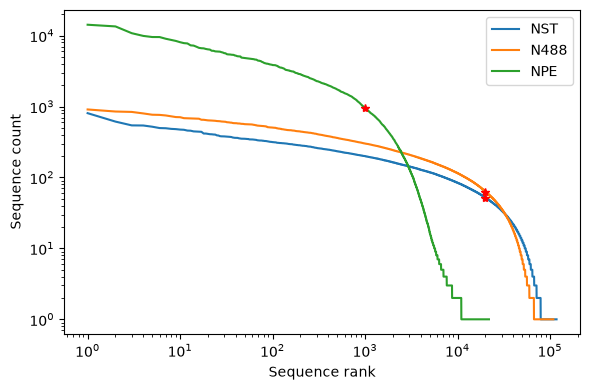

,sample,read calls,unique IDs,retained IDs,retained calls,retained fraction,minimum retained count
0,NST,3064508,117765,20000,1997732,0.651893,52
1,N488,3775924,108821,20000,2808854,0.743885,63
2,NPE,3175598,21877,1000,2190841,0.689899,949


In [3]:
cuts = [20000,20000,1000] # stringent
counts_by_sample = {}
retained = {}
block_freq = {}
summary = []
fig, ax = plt.subplots(figsize=(6, 4))
for sample, cutoff in zip(samples, cuts):
    path = INPUT / f'sample_{sample}.txt'
    opener = open if path.exists() else gzip.open
    if not path.exists():
        path = path.with_suffix('.txt.gz')
    with opener(path, 'rt') as handle:
        counts = Counter(line.strip() for line in handle if line.strip())
    assert all(len(ch) == 10 and set(ch) <= set('0123456789') for ch in counts)
    ranked = counts.most_common()
    assert len(ranked) >= cutoff
    counts_by_sample[sample] = counts
    filtered = ranked[:cutoff]
    retained[sample] = filtered
    ax.loglog(np.arange(1, len(ranked)+1), [n for _, n in ranked], label=sample)
    ax.plot(cutoff, filtered[-1][1], 'r*', label='_nolegend_')
    total = sum(n for _, n in filtered)
    frequencies = np.zeros((10, 10))
    for chimera, count in filtered:
        for position, parent in enumerate(chimera):
            frequencies[int(parent), position] += count
    frequencies /= total
    assert np.allclose(frequencies.sum(axis=0), 1)
    with np.errstate(divide='ignore'):
        block_freq[sample] = np.log10(frequencies)
    summary.append([sample, sum(counts.values()), len(counts), cutoff, total,
                    total/sum(counts.values()), filtered[-1][1]])
ax.legend()
ax.set(xlabel='Sequence rank', ylabel='Sequence count')
fig.tight_layout()
plt.show()
display(pd.DataFrame(summary, columns=['sample', 'read calls', 'unique IDs', 'retained IDs',
                                       'retained calls', 'retained fraction', 'minimum retained count']))

## 3. Inspect retained composition and sequence overlap

The heatmaps show which parents contribute to each block before and after selection. The overlap table counts retained IDs shared between samples; it does not weight them by abundance.

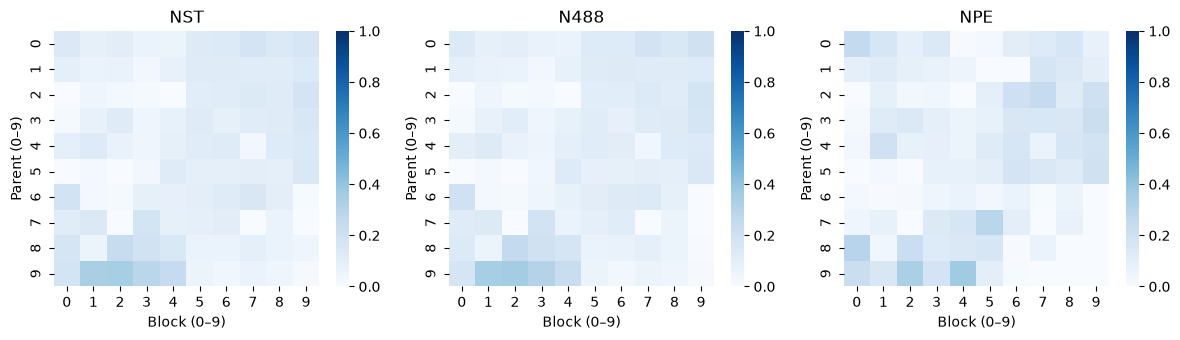

,NST,N488,NPE
NST,20000,7371,359
N488,7371,20000,67
NPE,359,67,1000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for sample, ax in zip(samples, axes):
    sns.heatmap(10 ** block_freq[sample], ax=ax, cmap='Blues', vmin=0, vmax=1)
    ax.set(title=sample, xlabel='Block (0–9)', ylabel='Parent (0–9)')
fig.tight_layout()
plt.show()
id_sets = {s: {ch for ch, _ in retained[s]} for s in samples}
display(pd.DataFrame([[len(id_sets[a] & id_sets[b]) for b in samples] for a in samples],
                     index=samples, columns=samples))

## 4. Figure 3A/B — block enrichment

Compute log10(selected block frequency / starting block frequency). As in the source notebook, blocks containing NheI (`GCTAGC`) or MluI (`ACGCGT`) sites are masked because those sites interfere with cloning. Undefined ratios are also left blank. No pseudocount is added to these block-level heatmaps.

The parent/block axes use the SI's zero-based numbering. Color ranges match the original plotting cells.

Masked restriction-site blocks: 7
N488e.eps range: -0.8920725187323104 0.08622963749440071


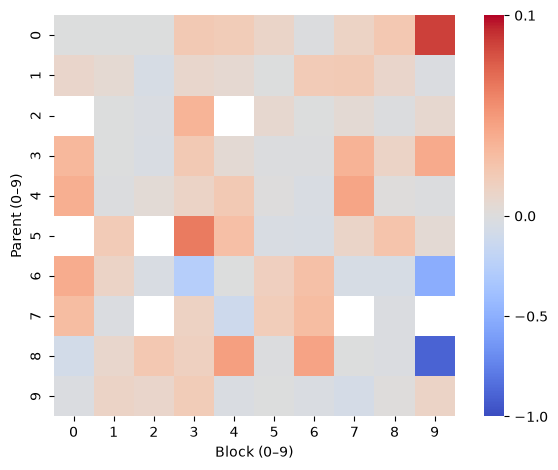

NPEe.eps range: -1.929118583910137 0.4973078209244225


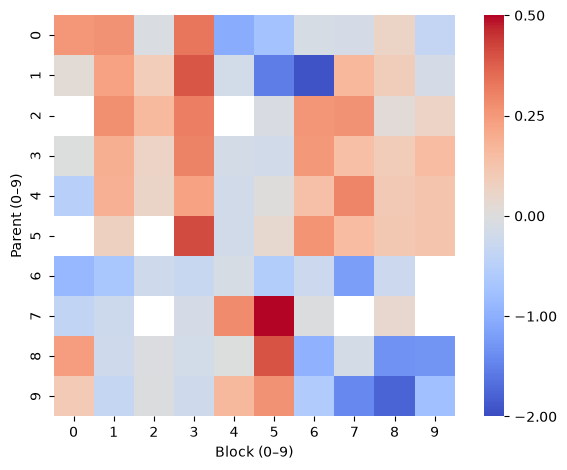

In [5]:
blocks_with_RE = np.ones((10, 10))
for position in range(10):
    for parent in range(10):
        if any(site in block_dict[position][parent] for site in ['GCTAGC', 'ACGCGT']):
            blocks_with_RE[parent, position] = np.nan
print(f"Masked restriction-site blocks: {np.isnan(blocks_with_RE).sum()}")
with np.errstate(invalid='ignore'):
    N488e = (block_freq['N488'] - block_freq['NST']) * blocks_with_RE
    NPEe = (block_freq['NPE'] - block_freq['NST']) * blocks_with_RE
for values, filename, limits, ticks in [
    (N488e, 'N488e.eps', (-1, .1), [-1, -.5, 0, .1]),
    (NPEe, 'NPEe.eps', (-2, .5), [-2, -1, 0, .25, .5]),
]:
    values[~np.isfinite(values)] = np.nan
    fig, ax = plt.subplots()
    sns.heatmap(values, cmap='coolwarm', norm=TwoSlopeNorm(vmin=limits[0], vcenter=0, vmax=limits[1]),
                square=True, cbar_kws={'ticks': ticks}, ax=ax)
    ax.set(xlabel='Block (0–9)', ylabel='Parent (0–9)')
    fig.tight_layout()
    fig.savefig(OUTPUT / filename)
    print(filename, 'range:', np.nanmin(values), np.nanmax(values))
    plt.show()

## 5. Figure 3C — diversity among retained activity-selected chimeras

Draw 10,000 independent pairs uniformly from the 1,000 retained NPE IDs, with replacement. This asks how different two distinct library sequences tend to be, rather than weighting by read abundance; a pair can contain the same ID twice.

As in the source notebook, distance counts unequal columns in a global amino-acid alignment, including gaps. The alignment parameters below are the explicit settings from the source notebook's comparison cell. A fixed seed makes reruns reproducible. The historical notebook did not record its random seed and was executed out of order, so its saved median of 51 is not guaranteed to reproduce. The median of this run is printed below.

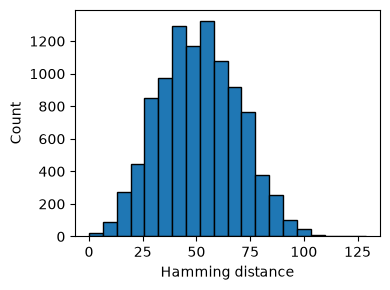

Median aligned distance: 51.0


In [6]:
aligner = PairwiseAligner(mode='global', match_score=2, mismatch_score=-2,
                         open_gap_score=-5, extend_gap_score=-1)
rng = np.random.default_rng(1)
PE_chimeras = [ch for ch, _ in retained['NPE']]
proteins = [chimera2AA(ch) for ch in PE_chimeras]
hamming = []
for i, j in rng.integers(0, len(proteins), size=(10000, 2)):
    alignment = aligner.align(proteins[i], proteins[j])[0]
    hamming.append(sum(a != b for a, b in zip(alignment[0], alignment[1])))
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(hamming, bins=20, edgecolor='black')
ax.set(xlabel='Hamming distance', ylabel='Count')
fig.tight_layout()
fig.savefig(OUTPUT / 'NPE_pwdist_hist.eps')
plt.show()
print('Median aligned distance:', np.median(hamming))

## 6. Figure 4C — identity of PETase and the selected chimeras

First reconstruct the four proteins from the SI blocks. The original notebook then sent sequences to an external alignment service and pasted back the percent-identity matrix. That saved matrix is retained verbatim to reproduce the panel; it is **not** newly calculated from the SI sequences. The original alignment file and complete service settings were not saved with the notebook.

In [7]:
clone_ids = {'PETase': '8888888888', 'R1': '9898974414',
             'R2': '4183135314', 'R3': '8807770303'}
display(pd.DataFrame([{'protein': name, 'chimera': ch, 'amino-acid sequence': chimera2AA(ch)}
                      for name, ch in clone_ids.items()]))

,protein,chimera,amino-acid sequence
0,PETase,8888888888,QTNPYARGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTN...
1,R1,9898974414,QTNPYQRGPDPTVSSLEATRGPFSTSSFTVSRPSGYGAGTVYYPTN...
2,R2,4183135314,AANPYERGPNPTDALLEARSGPFSVSEENVSRLGASGFGGGTIYYP...
3,R3,8807770303,QTNPYARGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTN...


In [8]:
# Archived external percent-identity matrix from the source notebook: 
out = """
#
#
#  Percent Identity  Matrix - created by Clustal2.1 
#
#

     1: petase      100.00   57.31   73.11   73.11
     2: R2           57.31  100.00   78.41   76.52
     3: R1           73.11   78.41  100.00   88.43
     4: R3           73.11   76.52   88.43  100.00
"""


In [9]:
iden = np.array([[float(n) for n in l.split()[2:]] for l in out.split('\n')[7:11]])
order = [0,2,1,3]
iden = iden[order][:, order]

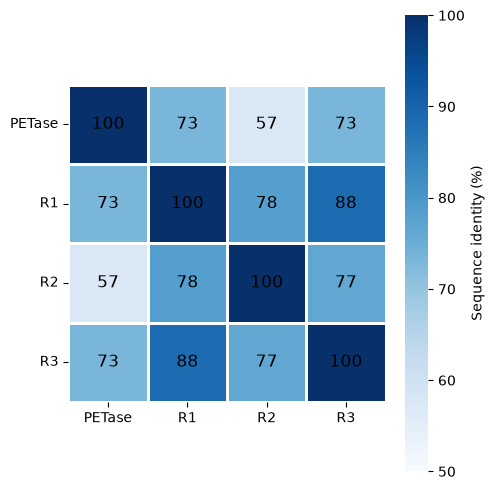

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(iden,annot=False,cmap="Blues",square=True,linewidths=1,linecolor="white",vmin=50,vmax=100,cbar_kws={"label": "Sequence identity (%)"},ax=ax)

for i in range(iden.shape[0]):
    for j in range(iden.shape[1]):
        ax.text(j + 0.5,i + 0.5,f"{iden[i, j]:.0f}",ha="center",va="center",color="black",fontsize=12)

plt.tight_layout()
ax.set_xticks(np.arange(4) + .5, list(clone_ids))
ax.set_yticks(np.arange(4) + .5, list(clone_ids), rotation=0)
fig.tight_layout()
fig.savefig(OUTPUT / 'PW_iden.eps')
plt.show()